# Лекция 1: Въведение в AI и ML

**От LLM до агенти** — Лекция 1 от 12

## Какво ще разгледаме днес

Основите: какво е езиков модел, как формулираме задачи в машинното самообучение и как изглежда най-простият езиков модел — n-gram. Ще завършим с ясна мотивация защо n-gram моделите не са достатъчни и какво идва следващо.

### Блокове

0. **Малко предистория**
1. **Какво е езиков модел?** [Обяснение] — основната идея + GPT-2 демо
2. **ML концепции през езиково моделиране** [Обяснение] — признаци, етикети, train/test, видове учене
3. **Разглеждане на текстов корпус** [Демо] — зареждаме и разглеждаме данни
4. **Пренагаждане, ъндърфитване и метрики** [Обяснение] — кога моделът е добър?
5. **Кой текст е по-добър?** [Дискусия] — сравняваме модели по интуиция
6. **Строим n-gram езиков модел** [Демо] — bigram и trigram стъпка по стъпка
7. **Генериране и оценка на текст** [Демо] — семплиране + перплексия
8. **Защо n-gram моделите опират до стена** [Обяснение] — мотивация за невронни мрежи
9. **Как представяме думите?** [Демо] — от one-hot вектори до embeddings

---
## Блок 1: Какво е езиков модел? [Обяснение]

**Цел:** Основната идея: езиковият модел предсказва следващия токен! 

### Езиковият модел: една проста идея

Какво правят ChatGPT, GitHub Copilot и другите големи езикови модели (LLM)?

**Предсказват следващия токен.**

Даден е текст (контекст), моделът определя вероятностно разпределение над всички възможни следващи токени и избира един. После повтаря.
![image.png](images/553032915f.png)
Нека видим това на практика с GPT-2 — модел с 124 милиона параметъра, публикуван от OpenAI през 2019.

In [1]:
from transformers import GPT2LMHeadModel, GPT2Tokenizer

model_name = "gpt2"
tokenizer = GPT2Tokenizer.from_pretrained(model_name)
model = GPT2LMHeadModel.from_pretrained(model_name)

print(f"Model: {model_name}")
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Model: gpt2
Parameters: 124,439,808


In [2]:
model

GPT2LMHeadModel(
  (transformer): GPT2Model(
    (wte): Embedding(50257, 768)
    (wpe): Embedding(1024, 768)
    (drop): Dropout(p=0.1, inplace=False)
    (h): ModuleList(
      (0-11): 12 x GPT2Block(
        (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (attn): GPT2Attention(
          (c_attn): Conv1D(nf=2304, nx=768)
          (c_proj): Conv1D(nf=768, nx=768)
          (attn_dropout): Dropout(p=0.1, inplace=False)
          (resid_dropout): Dropout(p=0.1, inplace=False)
        )
        (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (mlp): GPT2MLP(
          (c_fc): Conv1D(nf=3072, nx=768)
          (c_proj): Conv1D(nf=768, nx=3072)
          (act): NewGELUActivation()
          (dropout): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (ln_f): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  )
  (lm_head): Linear(in_features=768, out_features=50257, bias=False)
)

In [3]:
import torch

prompt = "Best football team in bulgaria "
input_ids = tokenizer.encode(prompt, return_tensors="pt")

with torch.no_grad():
    output = model.generate(
        input_ids,
        max_length=100,
        do_sample=True,
        temperature=1.5,
        top_k=50,
    )

generated_text = tokenizer.decode(output[0], skip_special_tokens=True)
print(generated_text)

The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


Best football team in bulgaria ????????@ToledoTurbo.co


Този модел — GPT-2 — генерира свързан текст токен по токен. Днес ще построим **най-простата версия** на езиков модел (n-gram), а през следващите лекции ще затворим разликата стъпка по стъпка:

- **Лекция 2:** Линейни модели → невронни мрежи
- **Лекции 3-5:** Токенизация → Внимание → Трансформатор
- **Лекция 6:** Обучение на пълен модел
- **Лекции 7-12:** Способности, съгласуване, локални модели, RAG, агенти

---
## Блок 2: ML концепции през езиково моделиране [Обяснение]

**Цел:** Основна ML терминология, представена изцяло чрез езикови задачи.

### Признаци (features) и етикети (labels)

В машинното самообучение винаги имаме:
- **Признаци (features)** — входни данни, от които моделът учи
- **Етикети (labels)** — това, което искаме да предскажем

При езиково моделиране:
- **Признаци:** предходните символи или думи (контекстът)
- **Етикет:** следващият символ или дума

![image.png](images/1a3e432d75.png)

Пример с модел на ниво знаци:

| Контекст (признаци) | Следващ символ (етикет) |
|---------------------|----------------------|
| `h` | `e` |
| `he` | `l` |
| `hel` | `l` |
| `hell` | `o` |

In [4]:
features = ["I", "love", "<Missing>", "eat", "ice", "cream"]
label = "to"

### Обучаващи, тестови и валидационни данни

Как знаем дали моделът **наистина е научил** нещо, а не просто е **запаметил** обучаващите данни?

Разделяме данните на три части:
- **Обучаващи данни (train)** — моделът учи от тях
- **Валидационни данни (validation)** — настройваме хиперпараметри
- **Тестови данни (test)** — финална оценка, без подглеждане

При езиковите модели: разделяме текстовия корпус на части и проверяваме дали моделът предсказва добре **текст, който не е виждал**.

### Видове учене

![image.png](images/ee9105ed14.png)
- **Обучение с учител (supervised):** имаме признаци + етикети. Пример: класификация на текст (спам / не спам).
- **Обучение без учител (unsupervised):** само признаци, без етикети. Пример: клъстеризация на документи по тема.
- **Обучение с подсилване (reinforcement learning):** моделът получава reward signal. Пример: RLHF — обучение на LLM с награди от друг модел обучен от човешка обратна връзка (Лекция 8).

Езиковото моделиране (предвиждане на следващ токен) е **self-supervised** — етикетите идват от самия текст, не са ръчно маркирани.

---
## Блок 3: Разглеждане на текстов корпус [Демо]

**Цел:** Практическа работа с данни — виждаме суровия материал преди да моделираме.

In [5]:
import os

In [6]:
with open("../data/ivan_vazov.txt", "r") as f:
    text = f.read()

print(f"Размер на корпуса: {len(text):,} символа")
print(f"\nПърви 300 символа:")
print(text[:300])

Размер на корпуса: 3,990,245 символа

Първи 300 символа:
﻿	Иван Вазов
	Драски и шарки

	I част
	Украсил столицата

	Всеки, който го познаваше преди две години, помни как беше съвсем други човек господин Бучински: лек, приятен и весел, винаги в добро разположение на духа, което имаше заразително действие въз другите. Той търсеше тогава обществото, което съ


In [7]:
len(text.split(' '))

626720

In [8]:
chars = sorted(set(text))
vocab_size = len(chars)

print(f"Уникални символи (речник): {vocab_size}")
print(f"Символи: {''.join(chars)}")

Уникални символи (речник): 197
Символи: 	
 !"#$()*,-./0123456789:;=>?ABCDEFGHIJLMNOPQRSTUVWXZ[]_`abcdefghijklmnopqrstuvwxyz{|}¤«¬µ»ÇàáâäçèéêëîòôöùΆΠάγεηινρστυІЈАБВГДЕЖЗИЙКЛМНОПРСТУФХЦЧШЩЪЫЭЮЯабвгдежзийклмнопрстуфхцчшщъыьэюяѐёіѣѫґ–—’“„…№﻿


In [9]:
from collections import Counter

char_counts = Counter(text)

print("Топ 15 символа по честота:")
for rank, (char, count) in enumerate(char_counts.most_common(100)):
    pct = count / len(text) * 100
    print(f" {rank+1}  {repr(char):6s}: {count:6,d} ({pct:.1f}%)")

Топ 15 символа по честота:
 1  ' '   : 626,719 (15.7%)
 2  'а'   : 372,132 (9.3%)
 3  'е'   : 274,930 (6.9%)
 4  'о'   : 268,535 (6.7%)
 5  'и'   : 259,487 (6.5%)
 6  'т'   : 212,588 (5.3%)
 7  'н'   : 189,684 (4.8%)
 8  'с'   : 147,005 (3.7%)
 9  'р'   : 138,620 (3.5%)
 10  'в'   : 134,618 (3.4%)
 11  'д'   : 107,072 (2.7%)
 12  'л'   : 103,895 (2.6%)
 13  'к'   : 102,488 (2.6%)
 14  'п'   : 80,672 (2.0%)
 15  'м'   : 77,718 (1.9%)
 16  'з'   : 66,921 (1.7%)
 17  ','   : 65,688 (1.6%)
 18  'я'   : 63,463 (1.6%)
 19  'ъ'   : 59,452 (1.5%)
 20  '\n'  : 57,390 (1.4%)
 21  'у'   : 53,483 (1.3%)
 22  'г'   : 51,612 (1.3%)
 23  'б'   : 50,065 (1.3%)
 24  '\t'  : 48,231 (1.2%)
 25  'ч'   : 41,483 (1.0%)
 26  '.'   : 36,397 (0.9%)
 27  'ш'   : 31,975 (0.8%)
 28  'х'   : 27,635 (0.7%)
 29  'й'   : 27,378 (0.7%)
 30  'ж'   : 23,325 (0.6%)
 31  '—'   : 19,057 (0.5%)
 32  'щ'   : 18,716 (0.5%)
 33  'ц'   : 17,212 (0.4%)
 34  'Т'   :  8,995 (0.2%)
 35  '!'   :  7,978 (0.2%)
 36  '…'   :  7,181 (0.

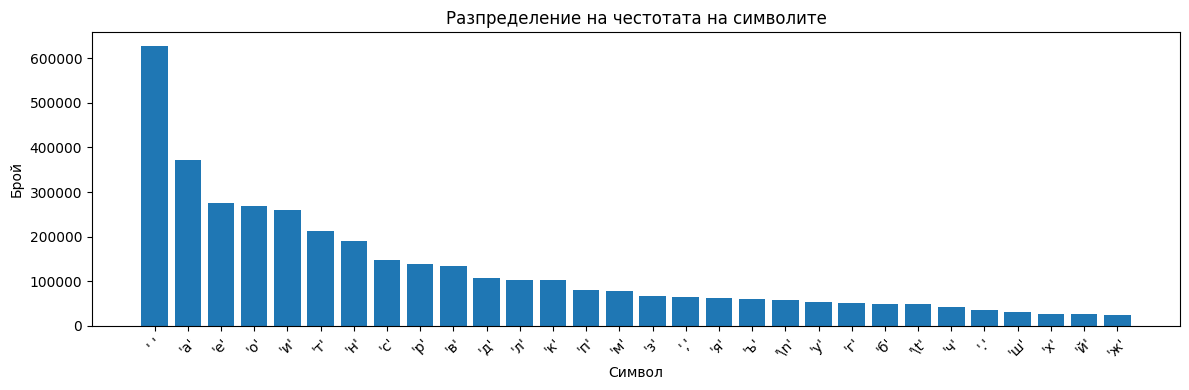

In [10]:
import matplotlib.pyplot as plt

top_chars = char_counts.most_common(30)
labels = [repr(c) for c, _ in top_chars]
values = [v for _, v in top_chars]

plt.figure(figsize=(12, 4))
plt.bar(labels, values)
plt.title("Разпределение на честотата на символите")
plt.xlabel("Символ")
plt.ylabel("Брой")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [11]:
# Разбиване на текста и изчистване на думите
import re

def split_into_words(text: str) -> list[str]:
   return re.findall(r"[\w]+(?:'[\w]+)*", text.lower(), flags=re.UNICODE)

In [12]:
#words = text.split()
words = split_into_words(text)

print(f"Общо думи: {len(words):,}")
print(f"Уникални думи: {len(set(words)):,}")

word_counts = Counter(words)
print("\nТоп 20 думи:")
for rank, (word, count) in enumerate(word_counts.most_common(200)):
    print(f" {rank+1}  {word:15s}: {count:5,d}")

Общо думи: 657,835
Уникални думи: 65,783

Топ 20 думи:
 1  и              : 26,655
 2  на             : 20,315
 3  се             : 15,886
 4  да             : 14,903
 5  в              : 11,965
 6  от             : 9,143
 7  с              : 8,800
 8  не             : 8,046
 9  си             : 8,025
 10  за             : 6,486
 11  е              : 6,206
 12  той            : 6,196
 13  му             : 5,369
 14  по             : 5,041
 15  че             : 4,073
 16  като           : 3,652
 17  го             : 3,573
 18  но             : 3,394
 19  беше           : 3,218
 20  аз             : 2,996
 21  ще             : 2,957
 22  това           : 2,636
 23  ти             : 2,527
 24  един           : 2,443
 25  ми             : 2,368
 26  тя             : 2,251
 27  а              : 2,247
 28  една           : 1,829
 29  ли             : 1,726
 30  ни             : 1,675
 31  те             : 1,651
 32  й              : 1,620
 33  при            : 1,590
 34  я              : 1,5

In [13]:
import pandas as pd

In [14]:
df = pd.Series(word_counts)

In [15]:
df[df == 3]

враждебен       3
оние            3
изразяват       3
разрешението    3
тежи            3
               ..
тунела          3
керова          3
наказанията     3
адютантин       3
партения        3
Length: 5003, dtype: int64

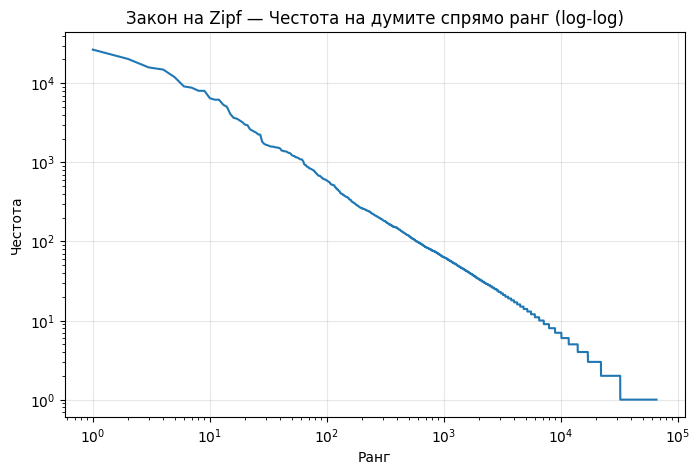

In [16]:
# Закон на Zipf: честотата на думите е обратно пропорционална на ранга
ranks = range(1, len(word_counts) + 1)
frequencies = [count for _, count in word_counts.most_common()]

plt.figure(figsize=(8, 5))
plt.loglog(ranks, frequencies)
plt.title("Закон на Zipf — Честота на думите спрямо ранг (log-log)")
plt.xlabel("Ранг")
plt.ylabel("Честота")
plt.grid(True, alpha=0.3)
plt.show()

Zipf's law: малко думи се срещат много често, повечето думи са редки. Това е фундаментална закономерност в езика и ще я виждаме отново при токенизация (Лекция 3).

In [17]:
# Train / test разделяне: 90% / 10%
split_idx = int(len(text) * 0.9)
train_text = text[:split_idx]
test_text = text[split_idx:]

print(f"Train: {len(train_text):,} символа ({len(train_text)/len(text)*100:.0f}%)")
print(f"Test:  {len(test_text):,} символа ({len(test_text)/len(text)*100:.0f}%)")

Train: 3,591,220 символа (90%)
Test:  399,025 символа (10%)


---
## Блок 4: Пренагаждане, ъндърфитване и метрики [Обяснение]

**Цел:** Да разберем кога моделът е твърде прост или твърде сложен и как измерваме качество.

### Пренагаждане (overfitting) и недообучаване (underfitting)

![image.png](images/6bcc891d3c.png)

При езиковите модели:
- **Недообучаване:** моделът не е уловил никакви закономерности — генерира почти случайни символи. Твърде прост е.
- **Пренагаждане:** моделът е запаметил тренировъчния текст дословно — перфектен на тренировачни данни, лош на нов текст. Вижда се при n-gram модели от висок ред с малко данни.
- **Добър баланс:** моделът е уловил реални закономерности в езика и генерализира.

### Перплексия (perplexity) — основната метрика за езикови модели

![image.png](images/lm_perplexity_timeline_bg.jpg)

**Перплексията** измерва колко "изненадан" е моделът от текста. По-ниска перплексия = по-добър модел.

**Интуиция:** ако моделът трябва да "познае" следващия символ от $V$ възможни, перплексията ни казва между колко варианта ефективно избира:
- Перплексия = $V$ (размер на речника) → модел който гадае на случаен принцип
- Перплексия = 1 → перфектен модел, винаги знае следващия символ

**Формула:**

$$PP(\text{text}) = \exp\left(-\frac{1}{N} \sum_{i=1}^{N} \log P(c_i \mid \text{context}_i)\right)$$

където $N$ е броят на предсказанията, а $P(c_i \mid \text{context}_i)$ е вероятността, която моделът дава на верния символ.

### Други метрики (кратко)

За задачи по **класификация** на текст (спам/не спам, sentiment анализ):
- **Точност (accuracy):** % верни предсказания — може да е подвеждаща при небалансирани класове
- **Precision / Recall / F1:** по-детайлна оценка на грешките

За нас фокусът не е **перплексията** — ще видим и други метрики.

---
## Блок 5: Кой текст е по-добър? [Дискусия]

**Цел:** Свързваме метриките с интуиция. Ще видим текст от различни "модели" и ще преценим качеството.

In [18]:
import random
random.seed(42)

# Текст A: случайни символи (равномерно разпределение)
random_text = ''.join(random.choice(chars) for _ in range(300))

print("=== Текст A ===")
print(random_text)

=== Текст A ===
м?$–nfaGґ=ц–У8аά)(9_cЙг$ЧWѐпьУΠ`ρЯo
…Mыά«oL_№¤=9è:Ç¬гk-ѣυСCç6ХsйзàЫVэ3-тbr6c;èoτлáNâ»[фlьчо4длPРѣfNІèmмщЦ`ш{﻿0b)xòl2]Щѐx]рЗîнυHkGg—ЧСk’ЮγЮòà`GКЖ9„.?LйMчάб2éèбЈПhХ чёAчС“l﻿н«?sηMτ	ёёkИ№RЙ>йtмЙдWLä№NТП	вzЕ"?àve0eЩ67ѫД3…Р﻿DDсБФOkПдά]Т„ѣщXяwòфпäιМσBga2¤#ЯХbЯ`
4юк1b3)|4ЛdoфД]ТEіЪЫБfБöU::сε»άùЈѣ/хро;1ôѣ¤>


In [19]:
# Текст B: unigram модел (семплиране по честота на символите)
char_list = list(char_counts.keys())
char_probs = [char_counts[c] / len(text) for c in char_list]

unigram_text = ''.join(random.choices(char_list, weights=char_probs, k=300))

print("=== Текст B ===")
print(unigram_text)

=== Текст B ===
  ро  Б
диа8дщяднс оаоП ,ро.Риен щикеаисдн.анит аб ичоикя е от  еарЯХа  яммонплшАт	п тяаааи ие т съдао 	ет еио	абъипина ъйдъ  а,бочнямНгмве яймг ,амд пр , в  мщ то—кяа-н. а
е исои ц	якеетоат  де  оо аоятъш и	 оитр
 ръйнаст пет  в рдаот лс т	ееаон.ка дрйт?ихбшеспиъер  тект а   ка лцаоко оъилдео	зедхо


In [20]:
# Текст C: изход от GPT-2 (от Блок 1)
print("=== Текст C ===")
print(generated_text[:300])

=== Текст C ===
Best football team in bulgaria ????????@ToledoTurbo.co


### Въпроси за дискусия

1. **Подредете текстовете** от най-лош до най-добър. По какви критерии решавате?
2. Текст A и Текст B използват същите символи. Защо B е по-добър?
3. Какво "знае" моделът зад Текст C, което липсва на другите?
4. Ако трябваше да дадете число за "качество" — как бихте го измерили?

След малко ще построим **bigram и trigram модели** и ще видим къде се нареждат между B и C.

---
## Блок 6: n-gram езиков модел [Демо]

**Цел:** Построяваме character-level bigram и trigram модели стъпка по стъпка.

![image.png](images/fb25211cc8.png)

### Bigram модел

**Bigram** = двойка последователни символи. Моделът предсказва следващия символ на базата само на **един** предходен символ:

$$P(c_i \mid c_{i-1})$$

In [21]:
# Броим всички bigram-и в обучаващите данни
bigram_counts = Counter()

for i in range(len(train_text) - 1):
    bigram = (train_text[i], train_text[i + 1])
    bigram_counts[bigram] += 1

print(f"Общо bigram-и: {sum(bigram_counts.values()):,}")
print(f"Уникални bigram-и: {len(bigram_counts):,}")
print(f"Възможни bigram-и: {vocab_size ** 2:,}")

Общо bigram-и: 3,591,219
Уникални bigram-и: 3,273
Възможни bigram-и: 38,809


In [22]:
# Съответствие символ → индекс
char_to_idx = {c: i for i, c in enumerate(chars)}
idx_to_char = {i: c for i, c in enumerate(chars)}

print(f"Речник: {vocab_size} символа")
print(f"Пример: '{chars[0]}' -> {char_to_idx[chars[0]]}, 'a' -> {char_to_idx['a']}")

Речник: 197 символа
Пример: '	' -> 0, 'a' -> 57


In [23]:
# Матрица с броячи за bigram-ите
bigram_matrix = torch.zeros(vocab_size, vocab_size, dtype=torch.float32)

for (c1, c2), count in bigram_counts.items():
    bigram_matrix[char_to_idx[c1], char_to_idx[c2]] = count

print(f"Размер на матрицата: {bigram_matrix.shape}")
print(f"Общо бройки: {bigram_matrix.sum().item():,.0f}")

Размер на матрицата: torch.Size([197, 197])
Общо бройки: 3,591,219


In [24]:
# Нормализация към вероятности (add-1 / Laplace smoothing)
bigram_probs = (bigram_matrix + 1) / (bigram_matrix.sum(dim=1, keepdim=True) + vocab_size)

print("Суми по редове (трябва да са ~1.0):")
print(bigram_probs.sum(dim=1)[:5])

Суми по редове (трябва да са ~1.0):
tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000])


Лапласово изглаждане: добавяме 1 към всички броячи. Без това, всеки bigram, който не сме видели, би имал вероятност 0 — и перплексията ще стане безкрайност.

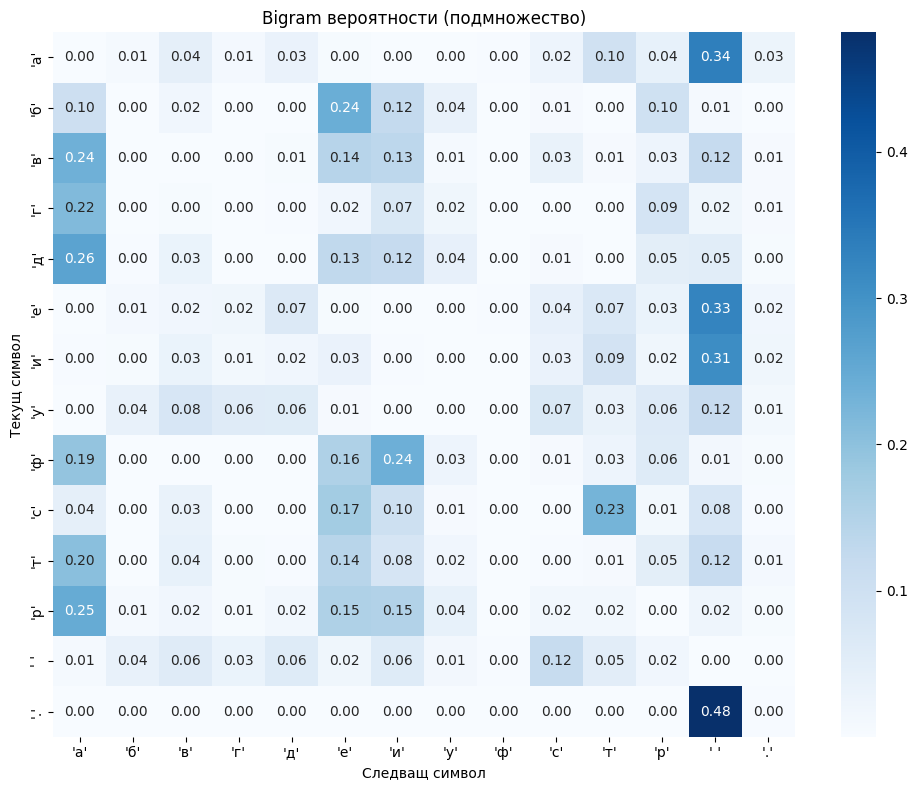

In [25]:
import seaborn as sns

# Визуализация на подмножество от bigram матрицата
subset_chars = list("абвгдеиуфстр .")
subset_idx = [char_to_idx[c] for c in subset_chars if c in char_to_idx]
subset_labels = [repr(chars[i]) for i in subset_idx]

plt.figure(figsize=(10, 8))
sns.heatmap(
    bigram_probs[subset_idx][:, subset_idx].numpy(),
    xticklabels=subset_labels,
    yticklabels=subset_labels,
    cmap="Blues",
    annot=True,
    fmt=".2f",
)
plt.title("Bigram вероятности (подмножество)")
plt.xlabel("Следващ символ")
plt.ylabel("Текущ символ")
plt.tight_layout()
plt.show()

In [26]:
import torch

def generate_text(bigram_probs, chars, char_to_idx, start_char='.', max_len=200):
    idx = char_to_idx[start_char]
    result = []
    
    while len(result) < max_len:
        probs = bigram_probs[idx]
        idx = torch.multinomial(probs, num_samples=1).item()
        char = chars[idx]
        if char == '.':
            break
        result.append(char)
    
    return ''.join(result)

print(generate_text(bigram_probs, chars, char_to_idx))

]Πдови с ни — плк! съсвалидиестъря


### Trigram модел

Разширяваме контекста: предсказваме следващия символ на базата на **два** предходни символа:

$$P(c_i \mid c_{i-2}, c_{i-1})$$

In [27]:
# Trigram модел: речник от (c1, c2) -> Counter на c3
trigram_counts = Counter()

for i in range(len(train_text) - 2):
    trigram = (train_text[i], train_text[i + 1], train_text[i + 2])
    trigram_counts[trigram] += 1

trigram_model = {}
for (c1, c2, c3), count in trigram_counts.items():
    key = (c1, c2)
    if key not in trigram_model:
        trigram_model[key] = Counter()
    trigram_model[key][c3] = count

print(f"Общо trigram-и: {sum(trigram_counts.values()):,}")
print(f"Уникални trigram-и: {len(trigram_counts):,}")
print(f"Уникални контексти: {len(trigram_model):,}")

Общо trigram-и: 3,591,218
Уникални trigram-и: 22,771
Уникални контексти: 3,273


In [28]:
import random

def generate_text_trigram(trigram_model, start_chars='..', max_len=200):
    c1, c2 = start_chars[0], start_chars[1]
    result = []

    while len(result) < max_len:
        key = (c1, c2)
        if key not in trigram_model:
            break
        
        counter = trigram_model[key]
        chars, counts = zip(*counter.items())
        total = sum(counts)
        probs = [c / total for c in counts]
        
        c3 = random.choices(chars, weights=probs, k=1)[0]
        
        if c3 == '.':
            break
        
        result.append(c3)
        c1, c2 = c2, c3

    return ''.join(result)

# Генериране на няколко примера
for _ in range(5):
    print(generate_text_trigram(trigram_model, 'Аз'))
    print()

 мира душе вижаснаха денинсти дваи ромбриятама телепра

 душка от неждогода бе ра

 едная за си,
	Сколно ли зах пориба, а е си, на и беше грото нители ко ска ги же виеряно обрат
	и за седмененци разите нас чевърд прозовеч!
	Огняван му пез Бюх извият в се едад хва каризчертий мир Мар

 фършини
	Тоглезор, чевна

 капея пръказагостветойте й мадения, на и ращ изду кате, ко зоразбях чайските, кръбто добой прина во свете
		и сите твой сокърдав то мисар Коздът откруглащинцу



---
## Блок 7: Генериране и оценка на текст [Демо]

**Цел:** Семплираме текст от моделите и измерваме качеството с перплексия.

In [29]:
def generate_bigram(probs, char_to_idx, idx_to_char, length=300, seed_char='\n'):
    result = [seed_char]
    idx = char_to_idx[seed_char]

    for _ in range(length):
        p = probs[idx]
        next_idx = torch.multinomial(p, 1).item()
        result.append(idx_to_char[next_idx])
        idx = next_idx

    return ''.join(result)

print("=== Генериран текст от bigram модел ===")
print(generate_bigram(bigram_probs, char_to_idx, idx_to_char))

=== Генериран текст от bigram модел ===

		Дужинат даразнаду наде впо терилещелои, ва по ко й и езрацещежича; паринкъгенамяте Гежде ни,
	…
	См призавена Данадоще г.
	— оре тита та пстатвизна нем тинетапре и, ве ситокъсъмасине в спл, Ки ПNхопосе Фоми Да
	Сюда ст. и сто и вални, еси н ве дв т За. скодносея ст п злоя брарапена ситя наве члогн


In [30]:
def generate_trigram(model, chars, length=300, seed="Th"):
    result = list(seed)

    for _ in range(length):
        key = (result[-2], result[-1])
        if key in model:
            counter = model[key]
            characters = list(counter.keys())
            weights = list(counter.values())
            next_char = random.choices(characters, weights=weights, k=1)[0]
        else:
            next_char = random.choice(chars)
        result.append(next_char)

    return ''.join(result)

print("=== Генериран текст от trigram модел ===")
print(generate_trigram(trigram_model, chars))

=== Генериран текст от trigram модел ===
Therenteint…
	I


	Соколиравай-лас.
	Гостазпри! Ти Не сът върство, ости кушваше е пългавнината броизвехите твието оти“ Никошенската стаморфото не, чуделаз,
	— Вът и тялоктовежки бедиха гласта си. Той чува все некаквани довен си машитекътна го ед бе сповихилен,
	никатано, отариде май-положавие. Честа е


Забелязваме: trigram текстът е **по-добър** от bigram. Повече контекст → по-реалистичен текст. Но и двата са далеч от GPT-2.

Нека измерим това числово с перплексия:

In [31]:
import math

def compute_perplexity_bigram(text, probs, char_to_idx):
    log_prob_sum = 0.0
    n = 0

    for i in range(len(text) - 1):
        c1, c2 = text[i], text[i + 1]
        if c1 in char_to_idx and c2 in char_to_idx:
            p = probs[char_to_idx[c1], char_to_idx[c2]].item()
            if p > 0:
                log_prob_sum += math.log(p)
                n += 1

    return math.exp(-log_prob_sum / n)

train_ppl = compute_perplexity_bigram(train_text, bigram_probs, char_to_idx)
test_ppl = compute_perplexity_bigram(test_text, bigram_probs, char_to_idx)

print(f"Bigram перплексия (train): {train_ppl:.2f}")
print(f"Bigram перплексия (test):  {test_ppl:.2f}")

Bigram перплексия (train): 12.21
Bigram перплексия (test):  12.43


In [32]:
# Сравнение: колко по-добър е bigram спрямо случайно гадаене?
uniform_ppl = vocab_size

print(f"Равномерна (случайна) перплексия: {uniform_ppl}")
print(f"Bigram перплексия (test):         {test_ppl:.2f}")
print(f"\nBigram е {uniform_ppl / test_ppl:.1f}x по-добър от случайно гадаене")

Равномерна (случайна) перплексия: 197
Bigram перплексия (test):         12.43

Bigram е 15.8x по-добър от случайно гадаене


**Резултати за PTB данните на английски:**

| Модел | Перплексия (test) | Качество |
|-------|------------------|----------|
| Random (uniform) | ~65 | Случайни символи |
| Bigram | ~по-ниско | Частични закономерности |
| GPT-2 (124M) | ~30-50 | Свързан текст |

По-ниска перплексия = моделът е по-малко "изненадан" = по-добро предсказване.

#### Перплексията като метрика е много чувствителна към това как точно е нарязан текста на думи или знаци, колко думи се ползват за апро ксимация.

---
## Блок 8: Защо n-gram моделите опират до стена [Обяснение]

**Цел:** Ясна мотивация за невронните мрежи — мост към Лекция 2.

### Проблем 1: Data sparsity (разредени данни)

С увеличаване на n, повечето възможни n-grams **никога не се срещат** в корпуса:

In [33]:
# Разредеността расте експоненциално с n
total_bi = vocab_size ** 2
observed_bi = (bigram_matrix > 0).sum().item()

total_tri = vocab_size ** 3
observed_tri = len(trigram_counts)

print("=== Разредени данни ===")
print(f"Bigram-и:  {int(observed_bi):,} / {total_bi:,} наблюдавани ({observed_bi/total_bi*100:.1f}%)")
print(f"Trigram-и: {observed_tri:,} / {total_tri:,} наблюдавани ({observed_tri/total_tri*100:.1f}%)")
print(f"4-gram-и:  биха изисквали {vocab_size**4:,} записа")
print(f"5-gram-и:  биха изисквали {vocab_size**5:,} записа")

=== Разредени данни ===
Bigram-и:  3,273 / 38,809 наблюдавани (8.4%)
Trigram-и: 22,771 / 7,645,373 наблюдавани (0.3%)
4-gram-и:  биха изисквали 1,506,138,481 записа
5-gram-и:  биха изисквали 296,709,280,757 записа


### Проблем 2: Фиксиран контекстен прозорец

N-gram модел с n=3 вижда **само 2 символа** назад. Не може да улови дългосрочни зависимости:

```
"The king who ruled the seven kingdoms for many years finally ___"
```

Bigram вижда: `"y "` → ? Не знае нищо за "king" или "kingdoms".

![image.png](images/fcbf10bd17.png)

### Проблем 3: Няма генерализация

За n-gram модела думите "cat" и "kitten" нямат **нищо общо**. Всяка комбинация от символи е независима. Моделът не може да прехвърли знание от един контекст в друг.

Ами ако можехме:
- Да представим думите като **плътни вектори** (embeddings), където сходни думи са близо в пространството?
- Да **научим** тези представяния от данните?
- Да имаме модел, който **генерализира** за нови комбинации?

Точно това е следващата стъпка — **Лекция 2: От линейни модели до невронни мрежи.**

---
## Блок 9: Как представяме думите? [Демо]

**Цел:** Да видим разликата между one-hot и плътни вектори (embeddings) — и защо тя е ключова.

### One-hot представяне

В n-gram модела всеки символ е просто индекс в таблица. Ако го представим като вектор, получаваме **one-hot** вектор — всички стойности са 0, освен една 1:

$$\text{"a"} = [0, 0, ..., 1, ..., 0] \quad \text{(вектор с дължина } V \text{)}$$

Проблемът: **всички символи са еднакво далеч един от друг.** Няма понятие за сходство.

In [34]:
# One-hot вектори за три символа от нашия речник
import torch.nn.functional as F

example_chars = ['а', 'б', 'в']
for c in example_chars:
    one_hot = F.one_hot(torch.tensor(char_to_idx[c]), num_classes=vocab_size)
    print(f"'{c}' -> вектор с дължина {vocab_size}, сума = {one_hot.sum().item()}")

'а' -> вектор с дължина 197, сума = 1
'б' -> вектор с дължина 197, сума = 1
'в' -> вектор с дължина 197, сума = 1


In [35]:
# Косинусово сходство между one-hot вектори
from torch.nn.functional import cosine_similarity

a_vec = F.one_hot(torch.tensor(char_to_idx['а']), num_classes=vocab_size).float()
b_vec = F.one_hot(torch.tensor(char_to_idx['б']), num_classes=vocab_size).float()
space_vec = F.one_hot(torch.tensor(char_to_idx[' ']), num_classes=vocab_size).float()

print("Косинусово сходство (one-hot):")
print(f"  'а' и 'б': {cosine_similarity(a_vec.unsqueeze(0), b_vec.unsqueeze(0)).item():.2f}")
print(f"  'а' и ' ': {cosine_similarity(a_vec.unsqueeze(0), space_vec.unsqueeze(0)).item():.2f}")
print("\nВсички двойки дават 0 — one-hot не кодира никакво сходство.")

Косинусово сходство (one-hot):
  'а' и 'б': 0.00
  'а' и ' ': 0.00

Всички двойки дават 0 — one-hot не кодира никакво сходство.


### Плътни вектори (embeddings)

Алтернативата: представяме всеки токен като **кратък, плътен вектор** (напр. 768 числа), който моделът **научава** от данните. Сходни думи получават близки вектори.

GPT-2 вече има такъв слой — нека го разгледаме:

In [36]:
# Embedding матрицата на GPT-2
embedding_matrix = model.transformer.wte.weight.detach()

print(f"Форма: {embedding_matrix.shape}")
print(f"  → {embedding_matrix.shape[0]:,} токена, всеки представен с {embedding_matrix.shape[1]} числа")
print(f"\nПърви 5 стойности от вектора на 'hello':")
token_id = tokenizer.encode("hello")[0]
print(f"  token '{tokenizer.decode([token_id])}' (id={token_id}): {embedding_matrix[token_id][:5]}")

Форма: torch.Size([50257, 768])
  → 50,257 токена, всеки представен с 768 числа

Първи 5 стойности от вектора на 'hello':
  token 'hello' (id=31373): tensor([-0.0819, -0.1947,  0.0008, -0.1873, -0.3476])


In [37]:
embedding_matrix[token_id].size()

torch.Size([768])

In [38]:
# Сходство между думи в embedding пространството на GPT-2
def get_embedding(word):
    token_id = tokenizer.encode(word)[0]
    return embedding_matrix[token_id].unsqueeze(0)

pairs = [
    ("king", "queen"),
    ("king", "throne"),
    ("king", "banana"),
    ("dog", "cat"),
    ("dog", "calculator"),
    ("king", "crown")
]

print("Косинусово сходство (GPT-2 embeddings):")
for w1, w2 in pairs:
    sim = cosine_similarity(get_embedding(w1), get_embedding(w2)).item()
    print(f"  {w1:12s} ↔ {w2:12s}: {sim:.3f}")

Косинусово сходство (GPT-2 embeddings):
  king         ↔ queen       : 0.267
  king         ↔ throne      : 0.229
  king         ↔ banana      : 0.228
  dog          ↔ cat         : 0.382
  dog          ↔ calculator  : 0.208
  king         ↔ crown       : 0.248


In [39]:
token_id = tokenizer.encode("king")[0]

Семантично близки думи имат (НЯМАТ) по-високо сходство — моделът е (не)-научил това **само** от текст, без речник или ръчни правила.

### Преход към Лекция 2

В n-gram модела всеки символ е индекс → one-hot вектор → никакво сходство. Невронните мрежи заменят това с **embedding слой** — матрица от научени плътни вектори.

Как точно моделът **научава** тези вектори? Чрез градиентно спускане и обратно разпространение на сигнала — темата на следващата лекция.

---
## Обобщение

### Ключови наблюдения

1. **Езиковият модел предсказва следващия токен** — това е основната идея зад ChatGPT, Copilot и т.н.
2. **ML терминология:** признаци (контекст), етикети (следващ токен), train/test split, обучение с учител / без учител / с подсилване
3. **Перплексията** измерва качеството на езиков модел — по-ниска = по-добра
4. **N-gram модели** са най-простите езикови модели — броят последователности от символи и изграждат таблици с вероятности
5. **Повече контекст помага** (bigram < trigram), но n-gram моделите опират до стена заради разредени данни, фиксиран прозорец и липса на генерализация
6. **Embeddings** представят токени като плътни вектори, където сходни думи са близо — невронните мрежи научават тези вектори от данните
7. **Следваща стъпка:** как невронните мрежи учат тези представяния чрез градиентно спускане (Лекция 2)

---
## Ресурси

- **Speech and Language Processing** (Jurafsky & Martin), Chapter 3 — N-gram Language Models
- **Andrej Karpathy — "Let's build GPT"** (YouTube) — практическо изграждане на GPT от нулата
- **Hugging Face Transformers** documentation — работа с GPT-2 и други модели
- **nanoGPT** (GitHub: karpathy/nanoGPT) — минимална имплементация на GPT, която ще разглеждаме от Лекция 2
- **3Blue1Brown — "But what is a neural network?"** (YouTube) — визуална интуиция за невронни мрежи (подготовка за Лекция 2)